---

# LINE CHARTS

---

>---
>**Line Charts** are used for showing trends over time
>
>- `ax.plot(x-axis series, series_values`, *formatting options*`)`
>
>---
>**PRO TIPS:**
>
>- `Pivot tabular data` to turn each unique series into a DataFrame column, and set the datetime as the index
>- `Divide your series by the appropriate units` while plotting to simplify the **y-axis** scale
>
>---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [33]:
df = pd.read_csv('../Data/ca_housing.csv', parse_dates=['period_begin'])

# "resample()" alias: 
# s=Secondly, h=Hourly, D=Daily, 
# W=Weekly, MS=Month Start, ME=Month End
df = (df
    .pivot_table(index='period_begin', columns='region_name', 
                 values='median_active_list_price', aggfunc='sum')
    .resample('W').sum().round() 
)

display(df.head(3), df.tail(3))
df.info()

region_name,Los Angeles,San Diego,San Francisco
period_begin,,,
2017-01-08,611561.0,618571.0,1229019.0
2017-01-15,614061.0,621738.0,1233394.0
2017-01-22,617311.0,625821.0,1239977.0


region_name,Los Angeles,San Diego,San Francisco
period_begin,,,
2022-04-17,906782.0,902900.0,1290250.0
2022-04-24,906786.0,901983.0,1294000.0
2022-05-01,906745.0,901916.0,1295750.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 278 entries, 2017-01-08 to 2022-05-01
Freq: W-SUN
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Los Angeles    278 non-null    float64
 1   San Diego      278 non-null    float64
 2   San Francisco  278 non-null    float64
dtypes: float64(3)
memory usage: 8.7 KB


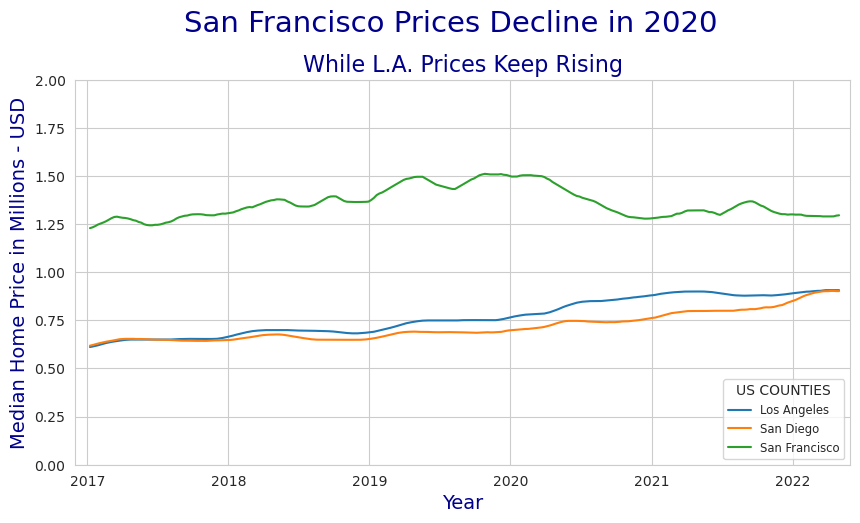

In [32]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
ax.plot(df/1e6)

fig.suptitle('San Francisco Prices Decline in 2020', fontsize=21, color='darkblue', y=1.02)
ax.set_title('While L.A. Prices Keep Rising', fontsize=16, color='darkblue')
ax.set_xlabel('Year', fontsize=14, color='darkblue')
ax.set_ylabel('Median Home Price in Millions - USD', fontsize=14, color='darkblue')

ax.set_xlim(pd.Timestamp('2016-12-01'), pd.Timestamp('2022-05-30'))
ax.set_ylim(0, 2)
    
ax.legend(df.columns, loc='lower right',
          title='US COUNTIES',
          fontsize='small', 
          title_fontsize='medium',
         )

plt.show()